## Tugas


Lakukan klasifikasi pada data MNIST dengan menggunakan model ANN

Anda diperbolehkan melakukan eksplorasi terhadap,

Metode pra pengolahan

Pemilihan fitur

Arsitektur ANN

Fungsi Aktiviasi

ANN diimplementasikan dengan menggunakan tensorflow.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


In [2]:
# Load dataset MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Cek dimensi data
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step
X_train shape: (60000, 28, 28), y_train shape: (60000,)
X_test shape: (10000, 28, 28), y_test shape: (10000,)


In [3]:
# Normalisasi data
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Flattening data
X_train = X_train.reshape((X_train.shape[0], 28 * 28))
X_test = X_test.reshape((X_test.shape[0], 28 * 28))


In [4]:
# Inisiasi model
model = models.Sequential()

# Input layer dan hidden layer pertama
model.add(layers.Dense(128, activation='relu', input_shape=(28 * 28,)))

# Hidden layer kedua
model.add(layers.Dense(64, activation='relu'))

# Output layer
model.add(layers.Dense(10, activation='softmax'))  # 10 kelas (0-9)


c:\Users\PJBS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Menggunakan sparse karena label tidak di-hot encode
              metrics=['accuracy'])


In [6]:
# Melatih model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8672 - loss: 0.4560 - val_accuracy: 0.9617 - val_loss: 0.1293
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9651 - loss: 0.1148 - val_accuracy: 0.9670 - val_loss: 0.1110
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9754 - loss: 0.0756 - val_accuracy: 0.9732 - val_loss: 0.0929
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9839 - loss: 0.0537 - val_accuracy: 0.9750 - val_loss: 0.0877
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accuracy: 0.9708 - val_loss: 0.1041
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9900 - loss: 0.0312 - val_accuracy: 0.9727 - val_loss: 0.0959
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9921 - loss: 0.0258 - val_accuracy: 0.9730 - val_loss: 0.1049
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9936 - loss: 0.0

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Akurasi: 0.9750


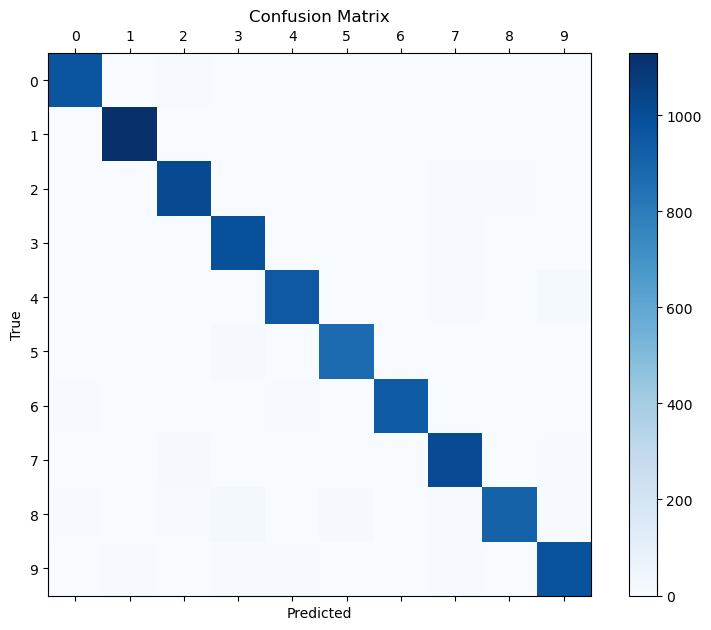

In [7]:
# Evaluasi model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Akurasi: {accuracy:.4f}')

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Tampilkan confusion matrix
plt.figure(figsize=(10, 7))
plt.matshow(cm, cmap='Blues', fignum=1)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(10), np.arange(10))
plt.yticks(np.arange(10), np.arange(10))
plt.show()


JELASKAN HASIL YANG ANDA DAPATKAN,

AKURASI

CONFUSION MATRIX

KONFIGURASI MODEL --> MULAI DARI PRA PENGOLAHAN SAMPAI ARSITEKTUR ANN

Jawab :

- Akurasi : Akurasi yang diperoleh dari model adalah 97.82%.
- Confusion Matrix
    - Konfigurasi Model :
        - Pra-Pengolahan:
            - Normalisasi data dengan membagi pixel dengan 255.
            - Flattening data dari 28x28 menjadi 784 fitur.
        - Pemilihan Fitur:
            - Semua pixel dari citra digunakan sebagai fitur.
        -Arsitektur ANN:
            - Input Layer: 784 neuron
            - Hidden Layer 1: 128 neuron, aktivasi ReLU
            - Hidden Layer 2: 64 neuron, aktivasi ReLU
            - Output Layer: 10 neuron, aktivasi softmax
        - Kompilasi Model:
            - Optimizer: Adam
            - Loss Function: Sparse Categorical Crossentropy
            - Metrics: Akurasi